In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import pandas as pd
import numpy as np

# Number of records
num_records = 10000

# Categories
issue_categories = [
    "Network",
    "Hardware",
    "Software",
    "Security",
    "Email",
    "Database"
]

priorities = [
    "Low",
    "Medium",
    "High",
    "Critical"
]

client_types = [
    "Small",
    "Medium",
    "Enterprise"
]

# Create dataset
df = pd.DataFrame({
    "Ticket_ID": range(100001, 100001 + num_records),
    "Issue_Category": np.random.choice(issue_categories, num_records),
    "Priority": np.random.choice(priorities, num_records, p=[0.35,0.35,0.20,0.10]),
    "Resolution_Time": np.round(np.random.uniform(0.5,12,num_records),2),
    "Engineer_Cost": np.random.randint(20,100,num_records),
    "Client_Type": np.random.choice(client_types,num_records,p=[0.5,0.3,0.2]),
    "Escalation_Count": np.random.randint(0,4,num_records),
    "Customer_Rating": np.round(np.random.uniform(2.5,5.0,num_records),1)
})

# Add 20% missing values
missing = df.sample(frac=0.2, random_state=42).index
df.loc[missing, "Resolution_Time"] = np.nan

df.head()


,Ticket_ID,Issue_Category,Priority,Resolution_Time,Engineer_Cost,Client_Type,Escalation_Count,Customer_Rating
0,100001,Database,High,NaN,94,Small,1,3.6
1,100002,Email,Critical,0.54,44,Small,2,2.8
2,100003,Hardware,Medium,6.48,98,Small,0,4.6
3,100004,Network,Low,NaN,66,Enterprise,2,3.7
4,100005,Software,Medium,10.58,70,Medium,3,3.1


In [3]:
df.to_csv("support_tickets.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [5]:
# Display first 5 rows
df.head()

,Ticket_ID,Issue_Category,Priority,Resolution_Time,Engineer_Cost,Client_Type,Escalation_Count,Customer_Rating
0,100001,Database,High,NaN,94,Small,1,3.6
1,100002,Email,Critical,0.54,44,Small,2,2.8
2,100003,Hardware,Medium,6.48,98,Small,0,4.6
3,100004,Network,Low,NaN,66,Enterprise,2,3.7
4,100005,Software,Medium,10.58,70,Medium,3,3.1


In [6]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Ticket_ID         10000 non-null  int64  
 1   Issue_Category    10000 non-null  object 
 2   Priority          10000 non-null  object 
 3   Resolution_Time   8000 non-null   float64
 4   Engineer_Cost     10000 non-null  int64  
 5   Client_Type       10000 non-null  object 
 6   Escalation_Count  10000 non-null  int64  
 7   Customer_Rating   10000 non-null  float64
dtypes: float64(2), int64(3), object(3)
memory usage: 625.1+ KB


In [7]:
# Summary statistics
df.describe()

,Ticket_ID,Resolution_Time,Engineer_Cost,Escalation_Count,Customer_Rating
count,10000.00000,8000.000000,10000.000000,10000.000000,10000.000000
mean,105000.50000,6.233367,59.828800,1.503700,3.759580
std,2886.89568,3.291695,23.094788,1.117457,0.723178
min,100001.00000,0.500000,20.000000,0.000000,2.500000
25%,102500.75000,3.360000,40.000000,1.000000,3.100000
50%,105000.50000,6.280000,60.000000,2.000000,3.800000
75%,107500.25000,9.060000,80.000000,3.000000,4.400000
max,110000.00000,12.000000,99.000000,3.000000,5.000000


In [8]:
# Check missing values
df.isnull().sum()


,0
Ticket_ID,0
Issue_Category,0
Priority,0
Resolution_Time,2000
Engineer_Cost,0
Client_Type,0
Escalation_Count,0
Customer_Rating,0


In [9]:
# Fill missing Resolution_Time with the median
df["Resolution_Time"] = df["Resolution_Time"].fillna(df["Resolution_Time"].median())

# Check if missing values remain
df.isnull().sum()

,0
Ticket_ID,0
Issue_Category,0
Priority,0
Resolution_Time,0
Engineer_Cost,0
Client_Type,0
Escalation_Count,0
Customer_Rating,0


In [10]:
# Create Total Cost feature
df["Total_Cost"] = df["Resolution_Time"] * df["Engineer_Cost"]

df.head()

,Ticket_ID,Issue_Category,Priority,Resolution_Time,Engineer_Cost,Client_Type,Escalation_Count,Customer_Rating,Total_Cost
0,100001,Database,High,6.28,94,Small,1,3.6,590.32
1,100002,Email,Critical,0.54,44,Small,2,2.8,23.76
2,100003,Hardware,Medium,6.48,98,Small,0,4.6,635.04
3,100004,Network,Low,6.28,66,Enterprise,2,3.7,414.48
4,100005,Software,Medium,10.58,70,Medium,3,3.1,740.60


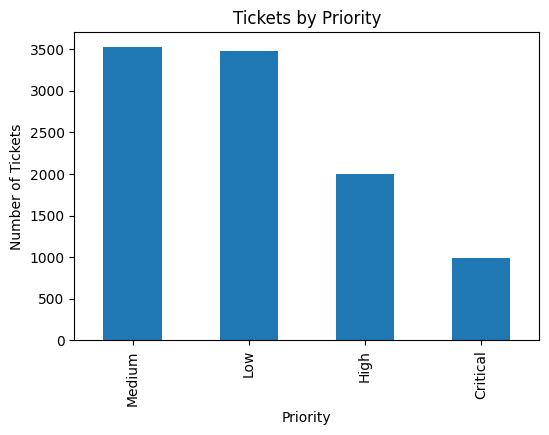

In [11]:
import matplotlib.pyplot as plt

priority_counts = df["Priority"].value_counts()

plt.figure(figsize=(6,4))
priority_counts.plot(kind="bar")
plt.title("Tickets by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.show()

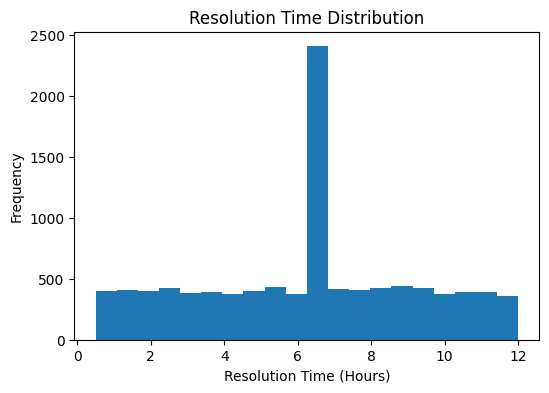

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df["Resolution_Time"], bins=20)
plt.title("Resolution Time Distribution")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Frequency")
plt.show()

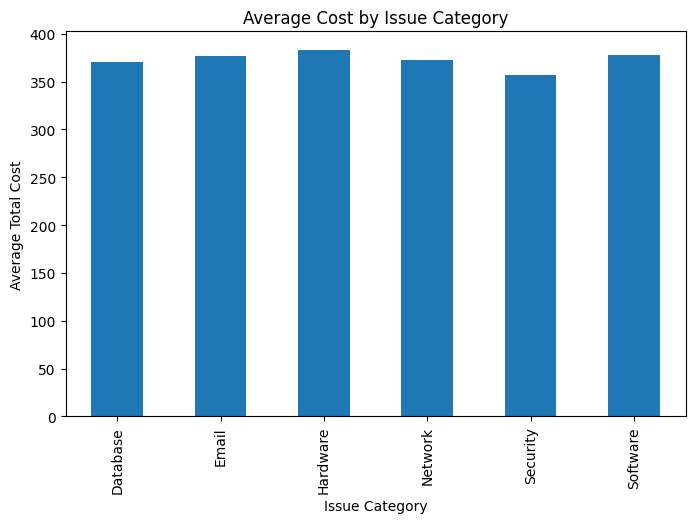

In [13]:
category_cost = df.groupby("Issue_Category")["Total_Cost"].mean()

plt.figure(figsize=(8,5))
category_cost.plot(kind="bar")
plt.title("Average Cost by Issue Category")
plt.xlabel("Issue Category")
plt.ylabel("Average Total Cost")
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder

# Make a copy
ml_df = df.copy()

# Convert text columns into numbers
le_issue = LabelEncoder()
le_priority = LabelEncoder()
le_client = LabelEncoder()

ml_df["Issue_Category"] = le_issue.fit_transform(ml_df["Issue_Category"])
ml_df["Priority"] = le_priority.fit_transform(ml_df["Priority"])
ml_df["Client_Type"] = le_client.fit_transform(ml_df["Client_Type"])

ml_df.head()

,Ticket_ID,Issue_Category,Priority,Resolution_Time,Engineer_Cost,Client_Type,Escalation_Count,Customer_Rating,Total_Cost
0,100001,0,1,6.28,94,2,1,3.6,590.32
1,100002,1,0,0.54,44,2,2,2.8,23.76
2,100003,2,3,6.48,98,2,0,4.6,635.04
3,100004,3,2,6.28,66,0,2,3.7,414.48
4,100005,5,3,10.58,70,1,3,3.1,740.60


In [15]:
from sklearn.model_selection import train_test_split

# Input features
X = ml_df[[
    "Issue_Category",
    "Priority",
    "Resolution_Time",
    "Engineer_Cost",
    "Client_Type",
    "Escalation_Count"
]]

# Target
y = ml_df["Total_Cost"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (8000, 6)
Testing samples: (2000, 6)


In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
predictions = model.predict(X_test)

predictions[:10]

array([286.7123, 215.0847, 538.4701, 570.4846, 538.9227, 563.2517,
       271.7344, 411.7224, 484.6913, 194.3162])

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Model Evaluation")
print("----------------")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,3))

Model Evaluation
----------------
MAE : 1.91
RMSE: 2.55
R² Score: 1.0


In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Resolution_Time,0.614368
3,Engineer_Cost,0.385415
0,Issue_Category,0.000073
5,Escalation_Count,0.000054
1,Priority,0.000050
4,Client_Type,0.000041


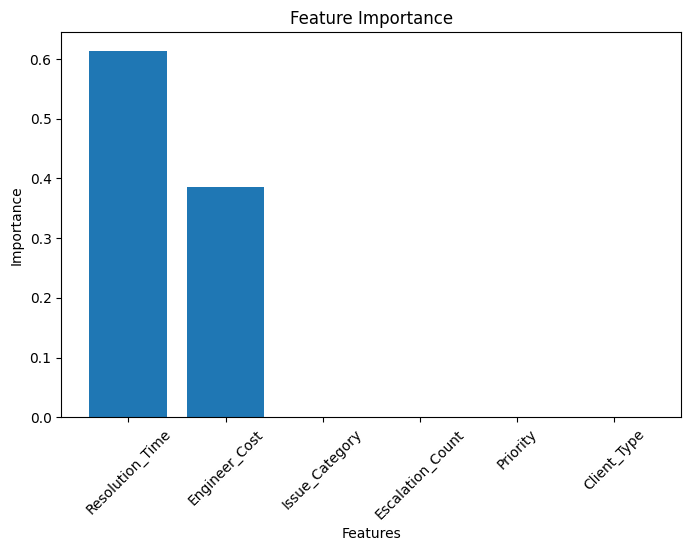

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


In [21]:
import joblib

joblib.dump(model, "cost_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
